In [1]:
import os
import torch
import argparse
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
from functools import partial
from torch import nn, optim
from matplotlib import pyplot as plt

from utils import sort_genes
from dl_utils import *

## load data of LINCS LDS-1593

In [2]:
data_dir = "../data/batch_data/LDS-1593/Data"
info_path = os.path.join(data_dir, "PromoCell-DGE-RNAseq-Experiment-Design.DCIC.xlsx")
sheets = ["SR1", "SR2", "SR4", "SR5"]
info_dfs = []
for i, sheet in enumerate(sheets):
    tmp = pd.read_excel(info_path, sheet_name = sheet)
    tmp["batch"] = i
    info_dfs.append(tmp)
info_df = pd.concat(info_dfs)
info_df["des1"] = info_df["State"].str.cat(info_df["Drug.Conc.1"].map(str) + info_df["Drug.Conc.Unit.1"].map(str), sep = "_").str.cat(info_df["Drug.Conc.2"].map(str) + info_df["Drug.Conc.Unit.2"].map(str), sep = "_")
info_df["des"] = info_df["Cell"].str.cat(info_df["des1"], sep = "_")
info_df.head()

,Cell,State,Well,Drug.Conc.1,Drug.Conc.Unit.1,Drug.Conc.2,Drug.Conc.Unit.2,batch,des1,des
0,A,TRS,A1,3.0,uM,NaN,NaN,0,TRS_3.0uM_nannan,A_TRS_3.0uM_nannan
1,A,URS,A2,20.0,uM,NaN,NaN,0,URS_20.0uM_nannan,A_URS_20.0uM_nannan
2,A,TRS+URS,A3,3.0,uM,20.0,uM,0,TRS+URS_3.0uM_20.0uM,A_TRS+URS_3.0uM_20.0uM
3,A,CTRL-EtOH,A4,0.0,nM,NaN,NaN,0,CTRL-EtOH_0.0nM_nannan,A_CTRL-EtOH_0.0nM_nannan
4,A,TRS,A5,3.0,uM,NaN,NaN,0,TRS_3.0uM_nannan,A_TRS_3.0uM_nannan


In [3]:
def read_data_lds1593(file_path, batch):
    data_df = pd.read_csv(file_path, sep = "\t").transpose().reset_index()
    data_df.columns = data_df.iloc[0]
    data_df = data_df.iloc[1:]
    data_df.rename({"Gene": "info"}, inplace = True, axis = 1)
    data_df["batch"] = batch
    data_df["Well"] = data_df["info"].apply(lambda x: x.split(".")[-1])
    data_df["Cell"] = data_df["info"].apply(lambda x: x.split(".")[1])
    ## exclude normalized data
    data_df = data_df[data_df["Well"] != "Norm"]
    return data_df
    
data_dfs = []
bat2label = {
    "Sequencing Experiment Number 1": 0,
    "Sequencing Experiment Number 2": 1,
    "Sequencing Experiment Number 4": 2,
    "Sequencing Experiment Number 5": 3}
trans_data_dir = os.path.join(data_dir, "Level3/Level3")
for dir_ in os.listdir(trans_data_dir):
    trans_data_dir_ = os.path.join(trans_data_dir, dir_)
    for file in os.listdir(trans_data_dir_):
        if dir_ == "Sequencing Experiment Number 5":
            for file_ in os.listdir(os.path.join(trans_data_dir_, file)):
                if "Human" not in file_:
                    continue
                file_path = os.path.join(trans_data_dir_, file, file_)
                batch = bat2label[dir_]
                data_df = read_data_lds1593(file_path, batch)
                data_dfs.append(data_df)
        else:       
            if "Human" not in file:
                continue
            file_path = os.path.join(trans_data_dir_, file)
            batch = bat2label[dir_]
            data_df = read_data_lds1593(file_path, batch)
            data_dfs.append(data_df)
data_raw = pd.concat(data_dfs)
data_raw = data_raw.dropna(axis='columns')
data_raw.shape

(2030, 10116)

In [4]:
data_raw = data_raw.drop_duplicates()
data_raw.shape

(709, 10116)

In [5]:
data_raw.head()

,info,A1BG,A2M,A4GALT,AAAS,AACS,AAED1,AAGAB,AAK1,AAMDC,...,ZWINT,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,batch,Well,Cell
1,CTRL.B.12.1.4.B1,27,186,5,18,2,5,12,23,70,...,1,1,3,39,3,4,21,2,B1,B
2,CTRL.B.18.1.4.B14,61,277,6,52,11,17,35,59,164,...,10,4,7,64,9,5,32,2,B14,B
3,CTRL.B.21.1.4.B22,38,161,6,30,2,5,22,22,96,...,4,3,6,32,2,1,17,2,B22,B
4,CTRL.B.23.1.4.C7,50,336,8,42,9,4,65,52,215,...,5,4,4,71,8,2,35,2,C7,B
5,CTRL.B.33.1.4.E23,90,417,19,70,13,11,50,51,218,...,9,10,7,80,13,6,29,2,E23,B


In [6]:
batches = data_raw.pop("batch").values.squeeze()
wells = data_raw.pop("Well").values.squeeze()
cells = data_raw.pop("Cell").values.squeeze()
data_raw.pop("info")

1      CTRL.B.12.1.4.B1
2     CTRL.B.18.1.4.B14
3     CTRL.B.21.1.4.B22
4      CTRL.B.23.1.4.C7
5     CTRL.B.33.1.4.E23
            ...        
9      VEM.A.61.3.5.F10
10     VEM.A.62.3.5.F15
5      DOX.E.66.2.5.G17
6      DOX.E.69.3.5.H10
7      DOX.E.71.3.5.H22
Name: info, Length: 709, dtype: object

In [7]:
infos = []
for cell, well, batch in zip(cells, wells, batches):
    this_info1 = info_df[info_df["batch"] == batch]
    this_info2 = this_info1[this_info1["Well"] == well]
    if len(this_info2) == 0:
        print(cell, well, batch)
    infos.append(this_info2["des"].values[0])
len(infos), len(set(infos))

(709, 181)

In [8]:
infos = np.array(infos)
Counter(infos)

Counter({'B_CTRL_0.0nM_nannan': 20,
         'D_CTRL_0.0nM_nannan': 18,
         'A_CTRL_0.0nM_nannan': 17,
         'E_CTRL_0.0nM_nannan': 15,
         'A_CTRL-DMSO_0.0nM_nannan': 10,
         'D_SUN_1.0uM_nannan': 8,
         'E_SOR_1.0uM_nannan': 7,
         'A_TRS_3.0uM_nannan': 5,
         'A_SUN_100.0nM_nannan': 5,
         'D_BOS_100.0nM_nannan': 4,
         'E_VEM_2.0uM_nannan': 4,
         'B_AXI_200.0nM_nannan': 4,
         'E_CAB_2.0uM_nannan': 4,
         'D_DAB_2.5uM_nannan': 4,
         'D_IMA_5.0uM_nannan': 4,
         'B_NIL_3.0uM_nannan': 4,
         'D_TOF_1.0uM_nannan': 4,
         'E_RUX_1.0uM_nannan': 4,
         'E_GEF_1.0uM_nannan': 4,
         'D_RUX_1.0uM_nannan': 4,
         'B_IMA_5.0uM_nannan': 4,
         'D_GEF_1.0uM_nannan': 4,
         'B_CRI_0.25uM_nannan': 4,
         'D_AXI_200.0nM_nannan': 4,
         'E_DAB_2.5uM_nannan': 4,
         'D_CRI_0.25uM_nannan': 4,
         'B_PAZ_10.0uM_nannan': 4,
         'A_GEF_1.0uM_nannan': 4,
         'E_VAN_333.0n

In [9]:
test_infos = []
for info in sorted(set(infos)):
    bs = batches[infos == info]
    if len(set(bs)) != 1:
        print(info, bs, len(bs))
        test_infos.append(info)
test_infos

A_CTRL_0.0nM_nannan [2 2 2 2 2 2 2 2 2 0 0 3 3 3 3 3 3] 17
B_CTRL_0.0nM_nannan [2 2 2 2 2 2 2 2 2 1 1 1 3 3 3 3 3 3 3 3] 20
D_CTRL_0.0nM_nannan [2 2 2 2 2 2 2 1 1 1 3 3 3 3 3 3 3 3] 18
D_SUN_1.0uM_nannan [2 2 2 2 3 3 3 3] 8
E_CTRL_0.0nM_nannan [2 2 2 2 2 2 2 2 2 2 2 3 3 3 3] 15
E_SOR_1.0uM_nannan [2 2 2 3 3 3 3] 7


['A_CTRL_0.0nM_nannan',
 'B_CTRL_0.0nM_nannan',
 'D_CTRL_0.0nM_nannan',
 'D_SUN_1.0uM_nannan',
 'E_CTRL_0.0nM_nannan',
 'E_SOR_1.0uM_nannan']

## sample normalization

In [10]:
data_sum = np.expand_dims(data_raw.sum(axis = 1).values, axis = 1)
data_raw = data_raw / data_sum * 10000.
data_raw.head()

,A1BG,A2M,A4GALT,AAAS,AACS,AAED1,AAGAB,AAK1,AAMDC,AAMP,...,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
1,0.405667,2.794593,0.075123,0.270444,0.030049,0.075123,0.180296,0.345568,1.051729,0.22537,...,0.240395,0.120198,0.105173,0.015025,0.015025,0.045074,0.585963,0.045074,0.060099,0.315519
2,0.356852,1.620457,0.0351,0.304201,0.06435,0.09945,0.204751,0.345152,0.959404,0.157951,...,0.07605,0.204751,0.140401,0.0585,0.0234,0.04095,0.374402,0.05265,0.02925,0.187201
3,0.444142,1.88176,0.070128,0.350639,0.023376,0.05844,0.257135,0.257135,1.122043,0.105192,...,0.070128,0.187007,0.128567,0.046752,0.035064,0.070128,0.374014,0.023376,0.011688,0.198695
4,0.307095,2.063679,0.049135,0.25796,0.055277,0.024568,0.399224,0.319379,1.320509,0.196541,...,0.116696,0.190399,0.165831,0.03071,0.024568,0.024568,0.436075,0.049135,0.012284,0.214967
5,0.42623,1.974865,0.089982,0.331512,0.061567,0.052095,0.236794,0.24153,1.032423,0.189435,...,0.085246,0.1847,0.142077,0.042623,0.047359,0.033151,0.378871,0.061567,0.028415,0.137341


## sort genes with intensities

In [11]:
sorted_cols = sort_genes(data_raw)
raw_data = data_raw[sorted_cols]
raw_data.head()

,SRCAP,MIER2,C22orf23,KDM4D,AKR7A3,TESK2,ZNF554,ENTHD2,SPATA6L,CAPN15,...,RPL34,TIMP1,COX3,RPS19,CYTB,RPLP1,FTL,COX1,SPARC,MALAT1
1,0.0,0.0,0.015025,0.030049,0.030049,0.015025,0.030049,0.030049,0.015025,0.0,...,73.801292,114.698507,80.877923,45.209301,136.288991,106.374827,190.272713,228.61573,257.989005,495.273983
2,0.01755,0.0234,0.01755,0.00585,0.0234,0.0117,0.0117,0.00585,0.00585,0.0234,...,85.328485,154.288596,86.030488,50.415527,144.735503,107.991487,185.989889,145.028004,278.121954,473.530386
3,0.011688,0.011688,0.0,0.011688,0.011688,0.0,0.023376,0.0,0.011688,0.0,...,103.601993,133.803656,85.485669,63.968153,134.586749,132.459542,205.474168,238.02511,237.23033,423.162245
4,0.006142,0.012284,0.0,0.024568,0.012284,0.012284,0.024568,0.006142,0.03071,0.012284,...,96.980641,103.484915,82.135662,67.474941,135.858884,111.887038,203.892738,123.347828,226.365959,468.78071
5,0.018944,0.033151,0.018944,0.018944,0.009472,0.004736,0.018944,0.018944,0.0,0.009472,...,95.958536,93.377478,74.670726,69.229192,117.236875,123.128318,176.81433,222.681393,300.013687,406.916857


## data preprocessing: logrithm transformation

In [12]:
raw_data_plus_1 = raw_data.values + 1
raw_data_plus_1 = raw_data_plus_1.astype("float64")
data = np.log(raw_data_plus_1)

## onehot transformation of batches

In [13]:
bat2label = {b:i for i, b in enumerate(sorted(set(batches)))}
label2bat = {i:b for i, b in enumerate(sorted(set(batches)))}
labels = np.array([bat2label[t] for t in batches])
labels_onehot = transform_hot(labels)
bat2label

{0: 0, 1: 1, 2: 2, 3: 3}

## model paths

In [14]:
db_name = "LDS1593"
model_dir = f"../models/batch-{db_name}"
out_dir = os.path.join(model_dir, f"test_{db_name}"); os.makedirs(out_dir, exist_ok = True)

## train & val & test for LINCS LDS-1593

In [15]:
rng = np.random.RandomState(0)

tot_test_idxs = np.array([t for t, info in enumerate(infos) if info in test_infos])
tot_train_val_idxs = np.array([t for t, info in enumerate(infos) if info not in test_infos])
tot_val_idxs = rng.choice(tot_train_val_idxs, size = int(0.2*len(tot_train_val_idxs)), replace = False)
tot_train_idxs = np.array([t for t in tot_train_val_idxs if t not in tot_val_idxs])

train_data, train_labels, train_labels_hot = data[tot_train_idxs], labels[tot_train_idxs], labels_onehot[tot_train_idxs]
val_data, val_labels, val_labels_hot = data[tot_val_idxs], labels[tot_val_idxs], labels_onehot[tot_val_idxs]
test_data, test_labels, test_labels_hot= data[tot_test_idxs], labels[tot_test_idxs], labels_onehot[tot_test_idxs]
train_ids, val_ids, test_ids = infos[tot_train_idxs], infos[tot_val_idxs], infos[tot_test_idxs]
print(train_data.shape, train_labels_hot.shape)
print(val_data.shape, val_labels_hot.shape)
print(test_data.shape, test_labels_hot.shape)

(500, 10112) (500, 4)
(124, 10112) (124, 4)
(85, 10112) (85, 4)


## network parameters setting

In [16]:
in_dim = raw_data.shape[1]
num_platform = len(bat2label)
batch_size = 256 ##256
hidden_dim = 256
z_dim = 128
drop = 0.3

ae = AE(in_dim, hidden_dim, num_platform, z_dim, drop).cuda()
ae.apply(weight_init)
net_param(ae)

5.687168

## load trained model & test

In [17]:
ae_sd = torch.load(os.path.join(model_dir, "ae.tar"))            
ae.load_state_dict(ae_sd)
ae.eval()

AE(
  (enc): Sequential(
    (0): Linear(in_features=10112, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=256, out_featu

In [18]:
sample_num = len(data)
iteration = int(np.ceil(sample_num/batch_size))
normed_data = np.ones_like(data)
for i in range(iteration):
    start = i*batch_size
    end = start + batch_size
    if end > sample_num: end = sample_num

    b_data = torch.FloatTensor(data[start:end]).cuda()
    rec_x = ae.dec(ae.enc(b_data))
    normed_data[start:end] = rec_x.detach().cpu().numpy()


## draw cluster map with rows and columns clutered

{0, 1, 2, 3}


<Figure size 1920x1440 with 0 Axes>

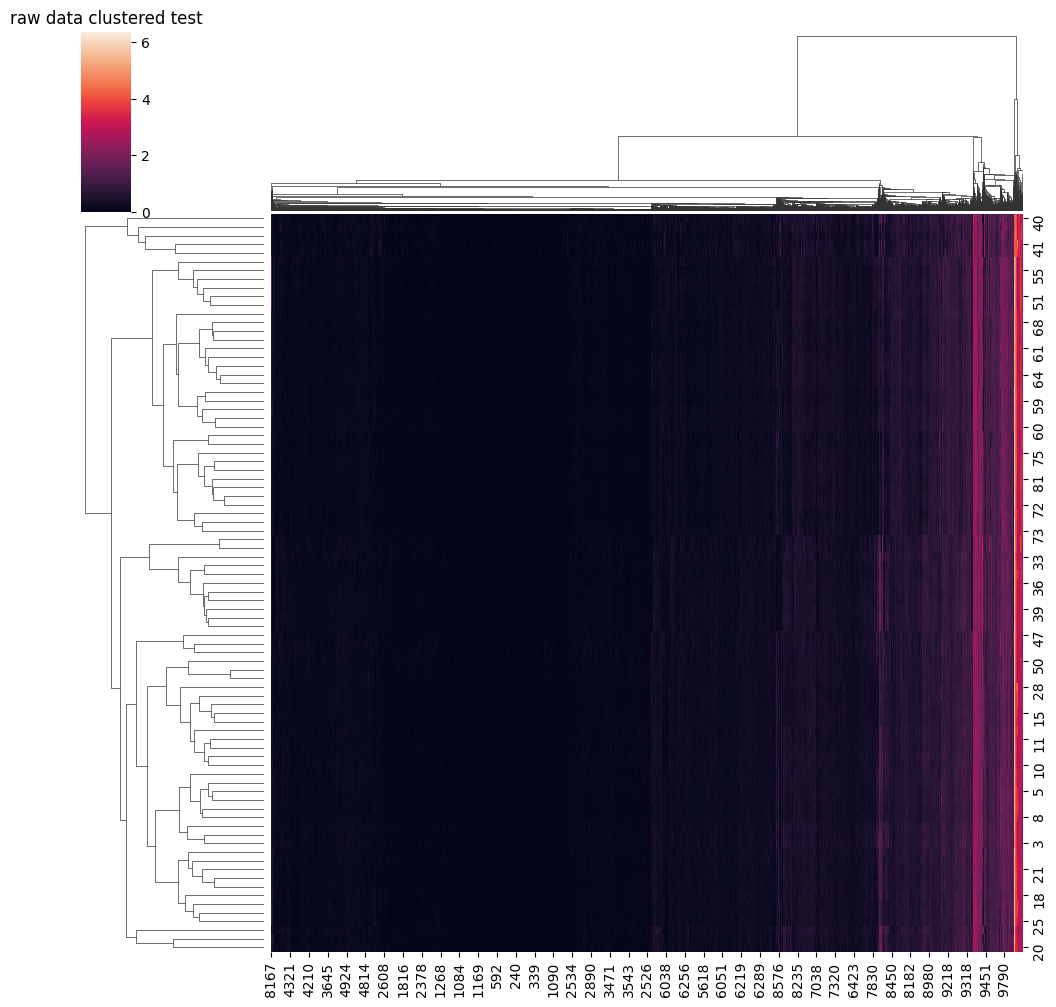

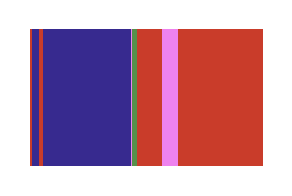

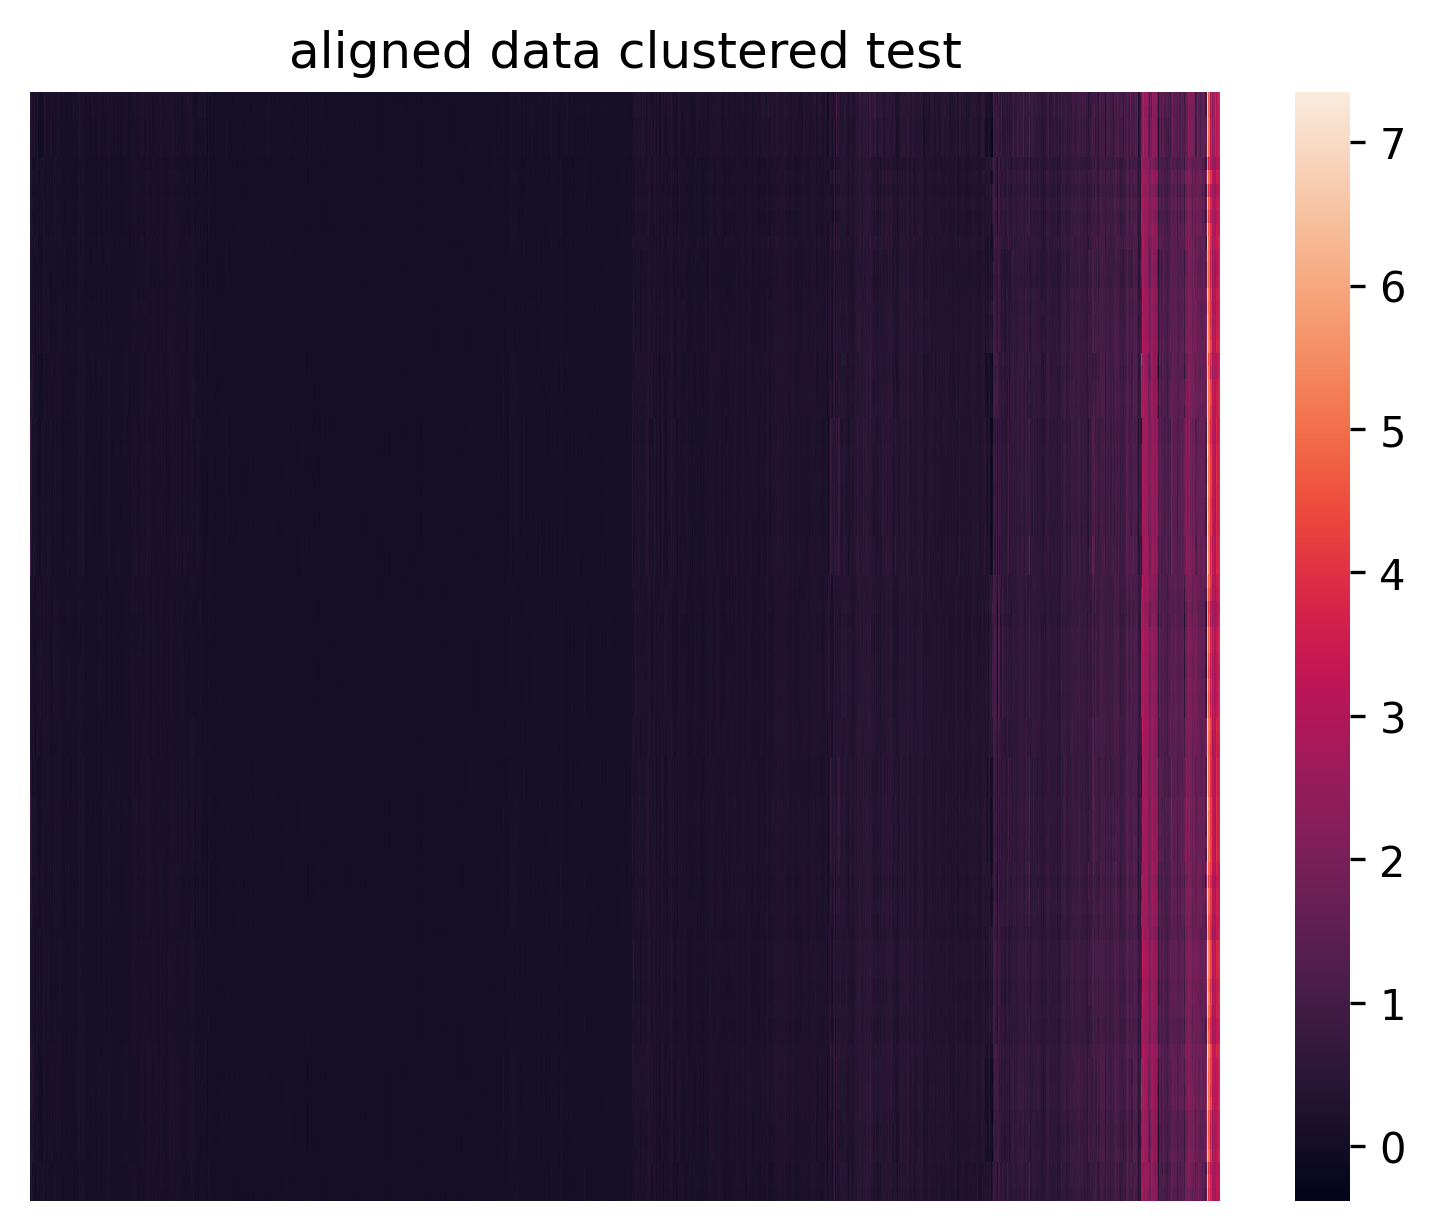

In [19]:
from importlib import reload
import heatmap_utils as HTM
reload(HTM)

colors = ["#57904B", "violet",  "#C93C2A", "#372A8F"]

drawer = HTM.HeatmapDrawer(out_dir)
rows, cols = drawer.draw_clustermap(labels[tot_test_idxs], data[tot_test_idxs], "raw data clustered test", colors)
drawer.draw_heatmap(normed_data[tot_test_idxs], "aligned data clustered test", rows, cols)

## decomposition analysis

/data2/DeepAI/Zhangmj/miniconda3/envs/pytorch/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/data2/DeepAI/Zhangmj/miniconda3/envs/pytorch/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/data2/DeepAI/Zhangmj/miniconda3/envs/pytorch/li

../models/batch-LDS1593/test_LDS1593/umap_raw_LDS1593.png 0.01102008801361339 0.006581623872108914 0.039709257196854655
../models/batch-LDS1593/test_LDS1593/umap_aligned_LDS1593.png 0.8558005838873832 0.8507732455508681 0.5434286342263


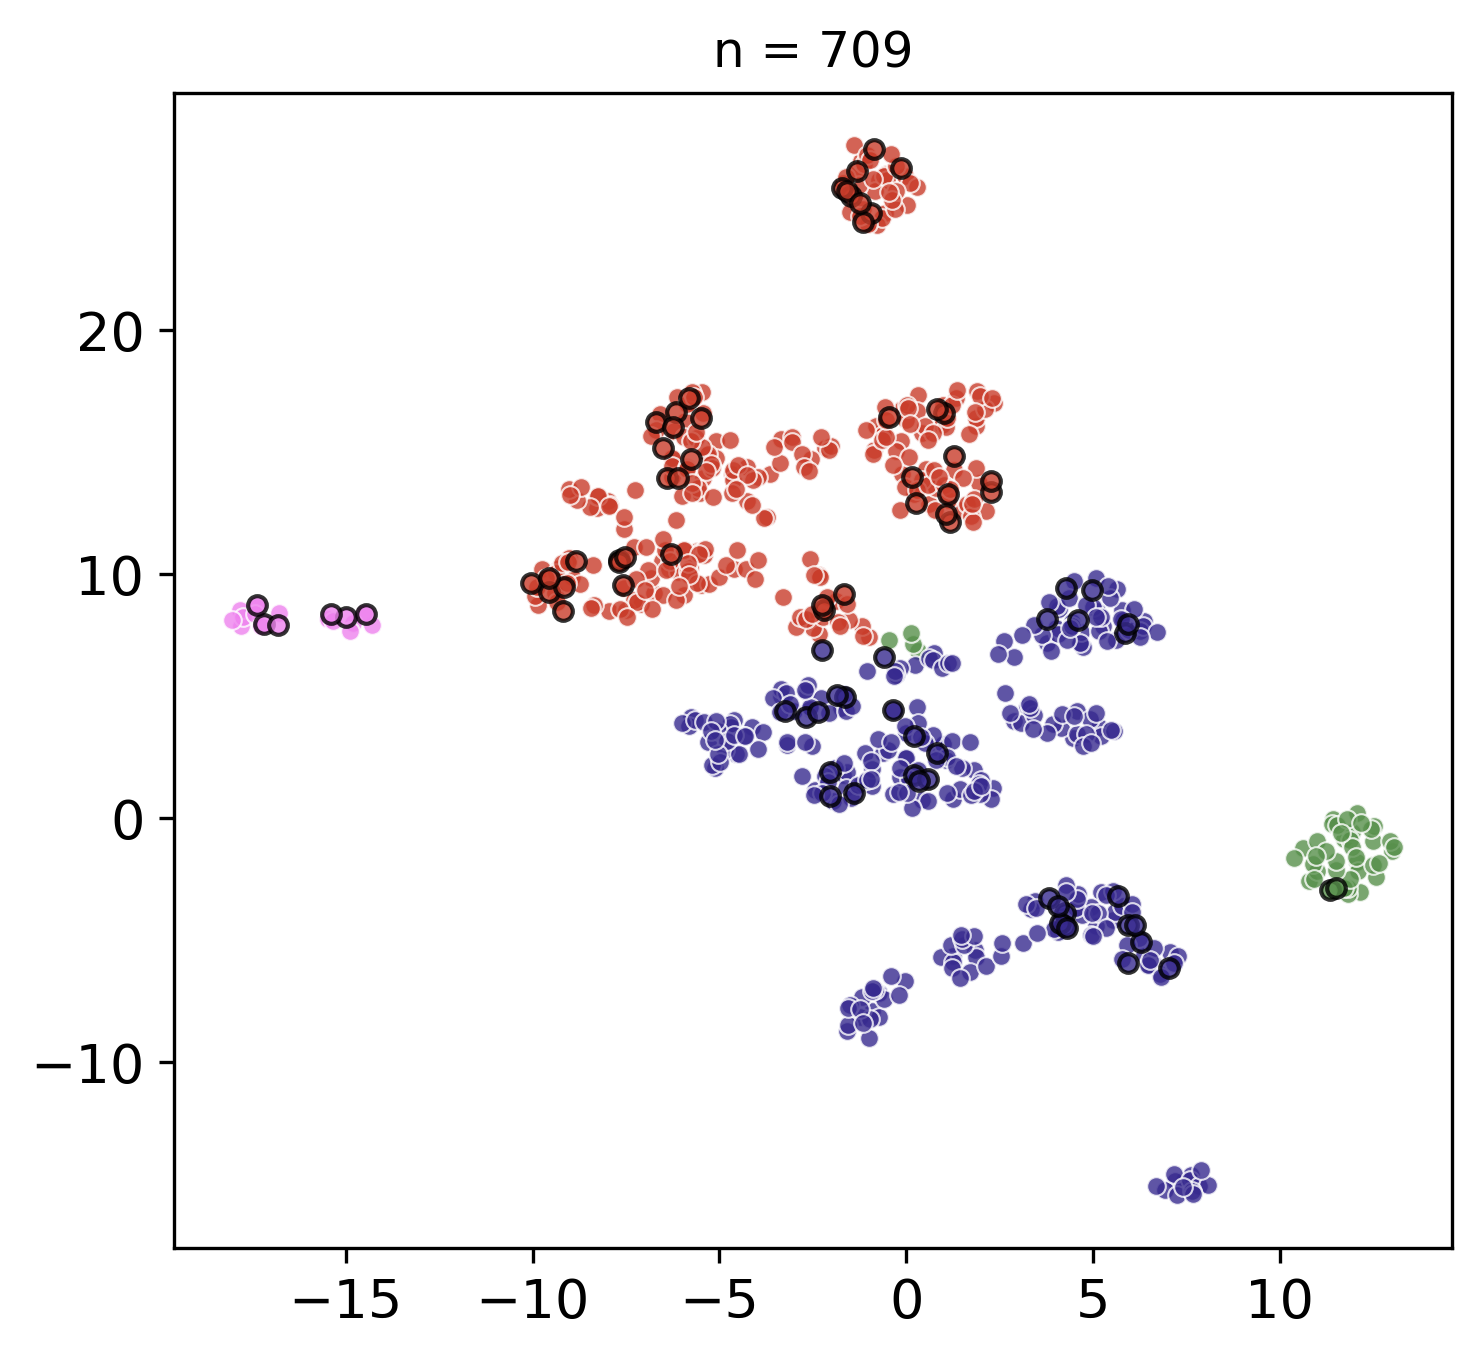

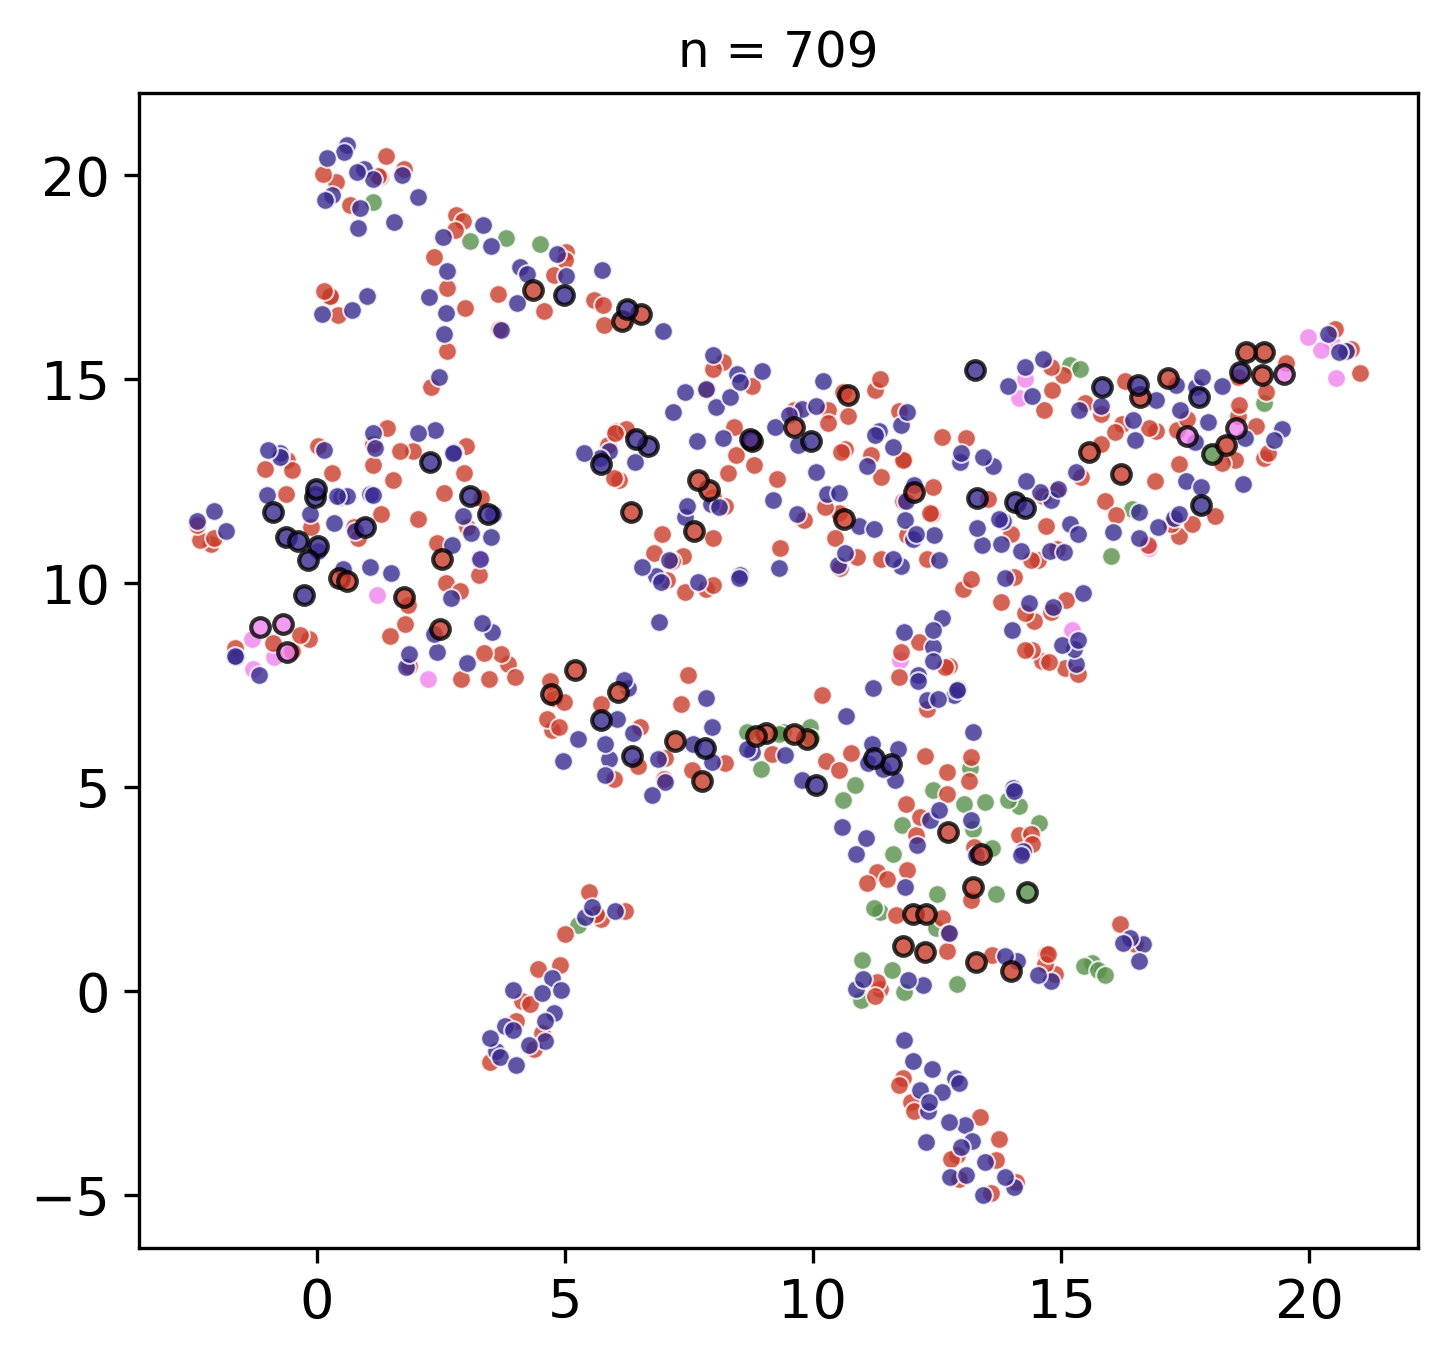

In [20]:
from importlib import reload

import decomposition_utils as DPU
reload(DPU)

fitter = "umap"
# colors = ["olive", "teal", "gold", "slateblue"]
colors = ["#57904B", "violet",  "#C93C2A", "#372A8F"]

trans_raw = DPU.decom_plot(
    data, labels, tot_train_val_idxs, tot_test_idxs, 
    os.path.join(out_dir, f"{fitter}_raw_{db_name}.png"), colors = colors, title = db_name,
    label2name = label2bat, fitter = fitter)

trans_aligned = DPU.decom_plot(
    normed_data, labels, tot_train_val_idxs, tot_test_idxs, 
    os.path.join(out_dir, f"{fitter}_aligned_{db_name}.png"), colors = colors, title = db_name, 
    label2name = label2bat, fitter = fitter)

../models/batch-LDS1593/test_LDS1593/umap_raw_LDS1593_participant_ctrl.png 0.1237699572571635 0.13251256174538736 0.024199843871974984
../models/batch-LDS1593/test_LDS1593/umap_aligned_LDS1593_participant_ctrl.png 0.24876383321647294 0.2430635323941594 0.18675135652401348


array([[18.328363 , 13.386731 ],
       [ 9.049734 ,  6.3249555],
       [16.199337 , 12.677799 ],
       ...,
       [12.732477 , -3.2104836],
       [12.950759 , -2.2561514],
       [12.390932 , -1.9075626]], dtype=float32)

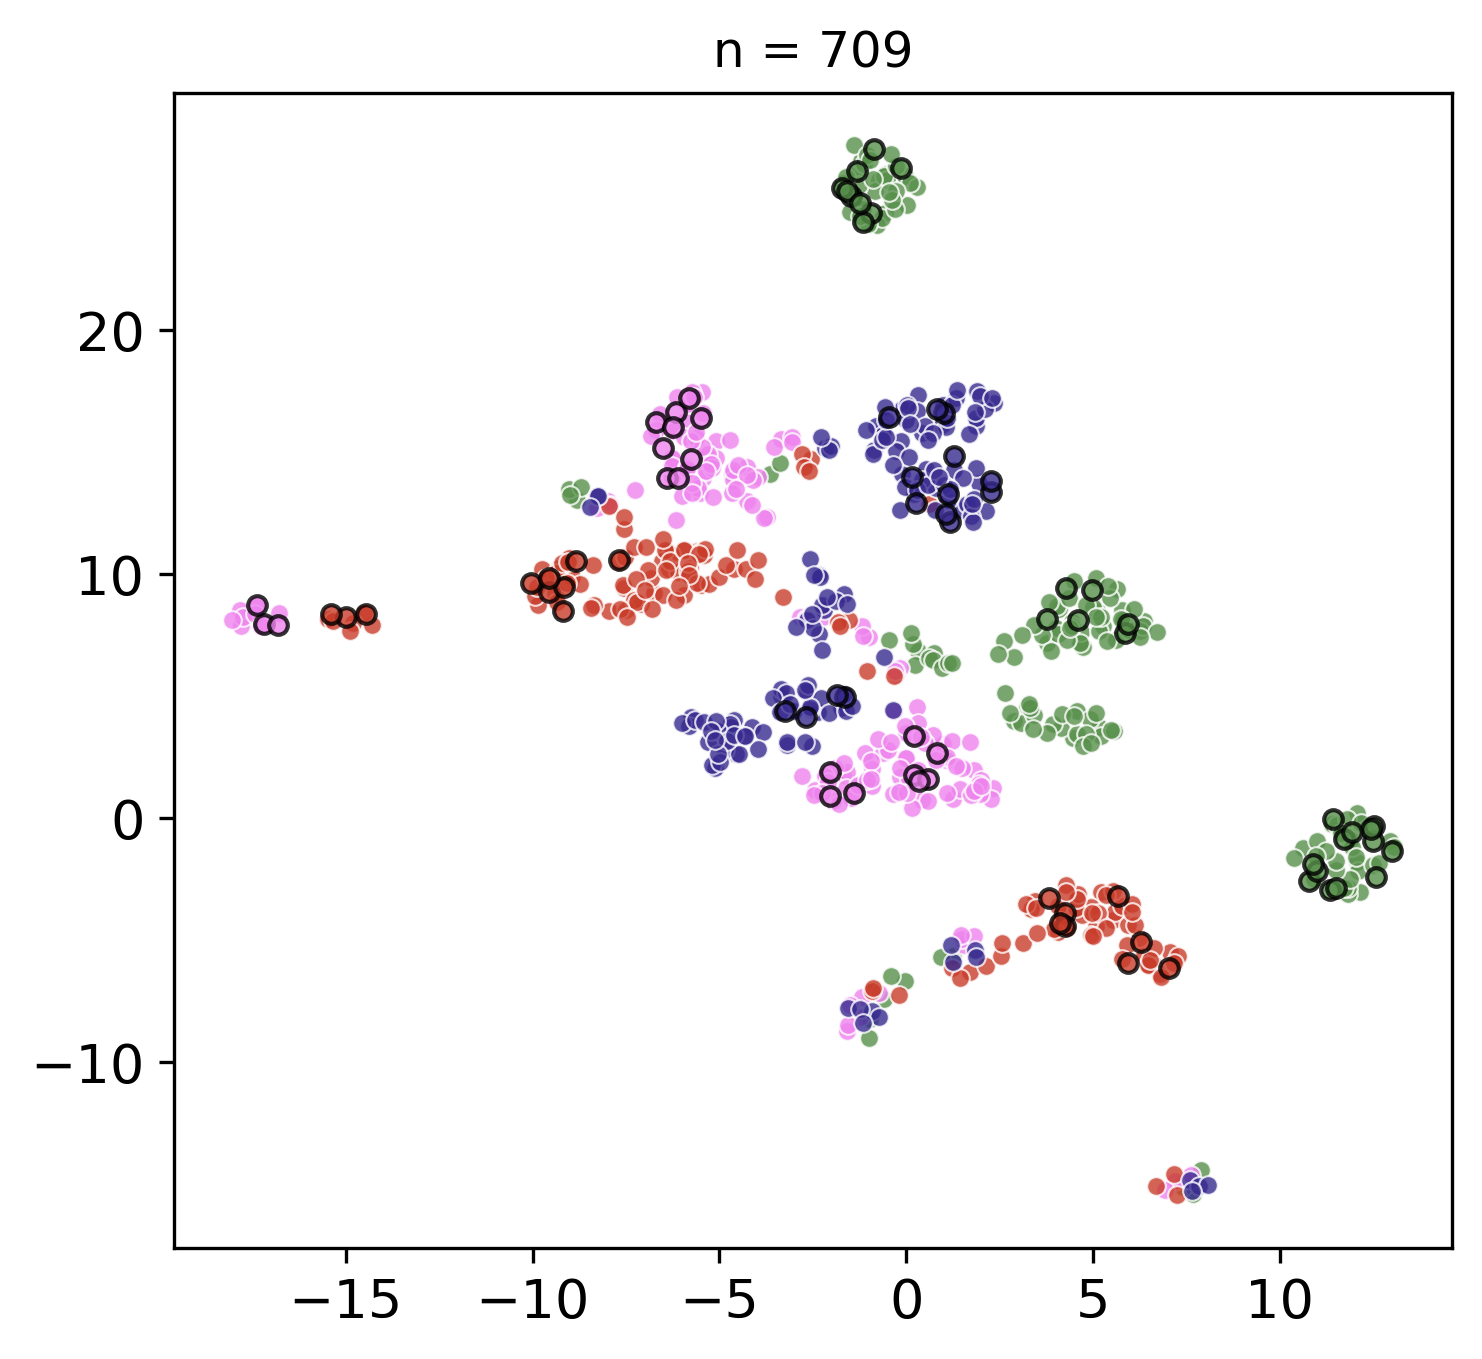

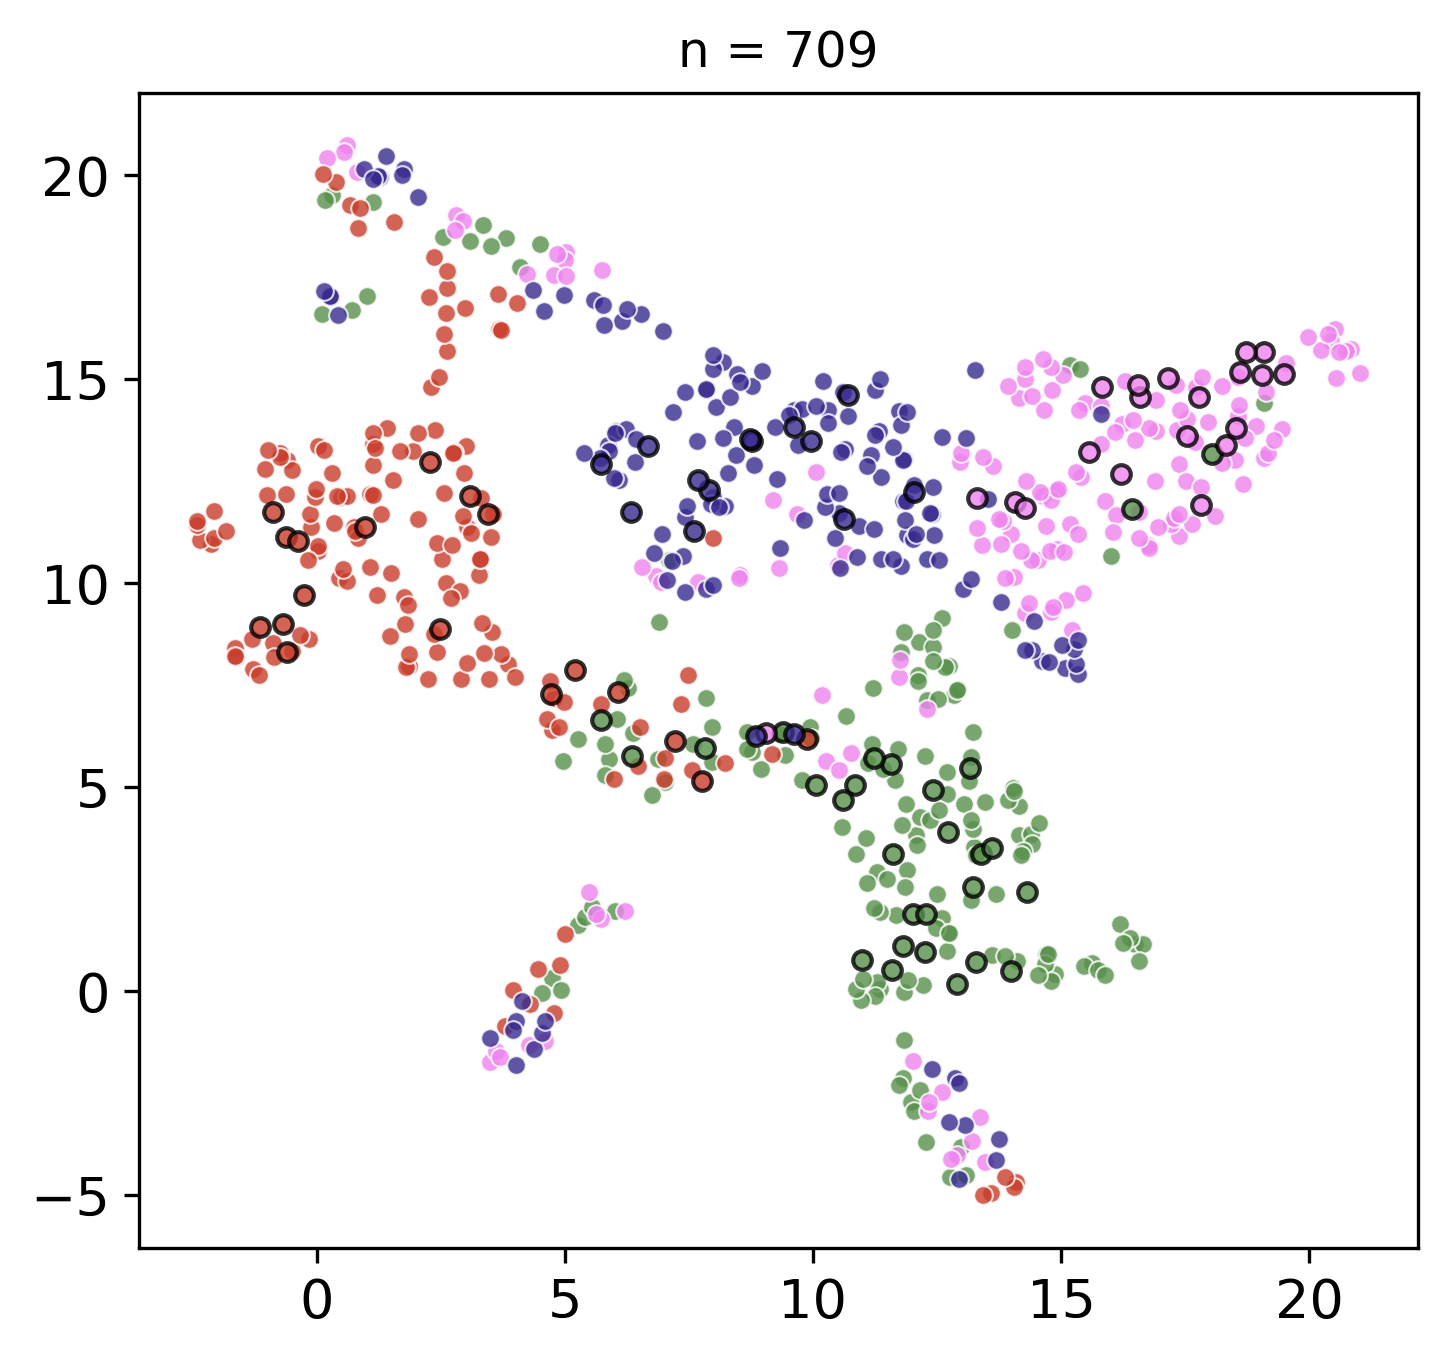

In [21]:
participants = np.array([info.split("_")[0] for info in infos])

ctrl_idxs = np.array([idx for idx, info in enumerate(infos) if "CTRL" in info])
nonctrl_idxs = np.array([idx for idx, info in enumerate(infos) if idx not in ctrl_idxs])

DPU.decom_plot(
    data, participants, nonctrl_idxs, ctrl_idxs, 
    os.path.join(out_dir, f"{fitter}_raw_{db_name}_participant_ctrl.png"), colors = colors, title = db_name, 
    label2name = {"A": "A", "B": "B", "D": "D", "E": "E"}, fitter = fitter)

DPU.decom_plot(
    normed_data, participants, nonctrl_idxs, ctrl_idxs, 
    os.path.join(out_dir, f"{fitter}_aligned_{db_name}_participant_ctrl.png"), colors = colors, title = db_name, 
    label2name = {"A": "A", "B": "B", "D": "D", "E": "E"}, fitter = fitter)